### Week 12: Follow Along Coding Practice
DSCI-590: Applied Data Science, Owen Randolph, 11/11/2024

In [6]:
import torch
import torchvision

if torch.cuda.is_available():
    device = torch.device('cuda:0')
    print('GPU available.')
else:
    device = torch.device('cpu')
    print('GPU not available, using CPU instead.')

GPU not available, using CPU instead.


In [7]:
# Reproducibility
import numpy as np
import random

torch.manual_seed(0)
torch.cuda.manual_seed(0)
np.random.seed(0)
random.seed(0)
torch.backends.cudnn.deterministic = True

In [8]:
import os
import torch
from torchvision import datasets, transforms

# We will see two different transform criteria, one for th training set and the other for the validation set.  Here is the dictionary of these transforms:
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])
}
print("Transforms defined.")
# Note that the values in transforms.  Normalize aren't the target mean and std.  They are the mean and std of the original data so that we can normalize by (X - \mu) / \sigma.
# Using this transform scheme, let's load the data using torchvision.datasets.ImageFolder(). We'll define a dictionary containing the training data and the test data.
# First, we need the folder directory containing the data.  I have added the whole zip file to the directory and will unzip it

import zipfile

with zipfile.ZipFile('archive (3).zip', 'r') as zip_ref:
    zip_ref.extractall()

data = {
    data_name: datasets.ImageFolder(os.path.join('hymenoptera_data', data_name), transform = data_transforms[data_name])
    for data_name in ['train', 'val']
}
print('Data loaded.')
print('Data dictionary keys:', data.keys())

# ImageFolder() method will be particularly useful when we have more classes.
# The list of class names in alphabetical order can be accessed by .classes
classes = data['train'].classes
print('Class names:', classes)

# This data should be further splitted for mini-batch.
# torch.utils.data.DataLoader() would do the job.
batch_size = 4
data_loader = {
    data_name: torch.utils.data.DataLoader(data[data_name], batch_size = batch_size, shuffle = True, num_workers = 4)
    for data_name in ['train', 'val']
}
print('DataLoader ready.')

Transforms defined.
Data loaded.
Data dictionary keys: dict_keys(['train', 'val'])
Class names: ['ants', 'bees']
DataLoader ready.


/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


#### Visualize the Data
This is not a necessary step but we always wish to see the images to make sure the code works as intended.  We will use the matplotlib.pyplot.imshow() to display and image.  The way imshow() understands an array as an image is slightly different from how our tensors recoreded the image data, so a permutation is necessary.
Also when we split the data for mini-batch, we set the batch size to 4.  torchvision.utils.make_grid enables us to turn a single-batch amount of images into a single (and horizontally longer) image.

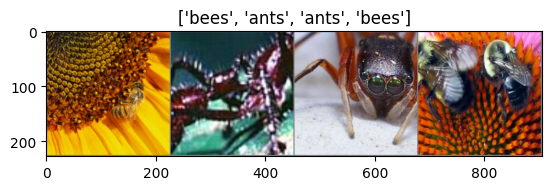

In [9]:
import matplotlib.pyplot as plt

def imshow(img_tensor, title = None):
    img = img_tensor.numpy().transpose((1, 2, 0))
    mean = np.ones(3) * 0.5
    std = np.ones(3) * 0.5
    img = img * std + mean
    plt.imshow(img)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)

# Now turn four images from a single batch into a single image grid
img_batch, class_batch = next(iter(data_loader['train']))
img_grid = torchvision.utils.make_grid(img_batch)
title = [classes[x] for x in class_batch]
imshow(img_grid, title = title)

#### Model
Here we implement the design of the network (layers and activations) as a single class.  The calss will not be completely original (just inheriting torch.nn.Module):
* The layers are from torch.nn methods
* The activation functions are imported from torch.nn.functional

The code itself reveals the network structure pretty clearly, so no description is given about explicit layers and which forwarding methods are used. Note that this example model has a far wekaer network structure than well-known pretrained networks.

In [10]:
import torch.nn as nn
import torch.nn.functional as F

class CustomModel(nn.Module):
  def __init__(self):
    super(CustomModel, self).__init__()
    self.conv1 = nn.Conv2d(3, 16, 5)
    self.pool = nn.MaxPool2d(2, 2)
    self.conv2 = nn.Conv2d(16, 16, 5)
    self.fc1 = nn.Linear(16 * 53 * 53, 120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84, 10)

  def forward(self, x):
    x = self.pool(self.conv1(x))
    x = self.pool(self.conv2(x))
    x = x.view(-1, 16 * 53 * 53)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x

model = CustomModel().to(device)

In [11]:
# Analysis on variable shapes between layers.  First, sample a batch of data:
input, label = next(iter(data_loader['train']))
print(input.shape)

torch.Size([4, 3, 224, 224])


In [12]:
# Track the tensor size in the first two hidden layers
x = input
print('x.shape:', x.shape)
# first forward
print('first forward')
x = nn.Conv2d(3, 16, 5)(x)
print('x.shape:', x.shape)
x = nn.MaxPool2d(2, 2)(x)
print('x.shape:', x.shape)
# second forward
print('second forward')
x = nn.Conv2d(16, 16, 5)(x)
print('x.shape:', x.shape)
x = nn.MaxPool2d(2, 2)(x)
print('x.shape:', x.shape)

x.shape: torch.Size([4, 3, 224, 224])
first forward
x.shape: torch.Size([4, 16, 220, 220])
x.shape: torch.Size([4, 16, 110, 110])
second forward
x.shape: torch.Size([4, 16, 106, 106])
x.shape: torch.Size([4, 16, 53, 53])


By the end, the tensor that is sent to the third layer (fully-connected linear layer fc1) consists of four "images", with 16 channels and 53 x 53 resolution each.  That's why we reshape the tensor with

In [13]:
x = x.view(-1, 16 * 53 * 53)

#### Model Training
We will put every training step into a single function. The key inputs to the function are:
* a model
* a loss function f,
* an optimizer for computing ∇f,
* a learning rate α for the update += α∗∇f,
* the number of epochs

The learning rate alpha can be adjusted as our estimated parameters get close to the true optimized values ( smaller alpha is preferred).
* For the implementaion, we use torch.optim.lr_scheduler

Even if alpha gets smaller ast he estimated parameters are close to the optimal, because of the way we use the performance optimaizer (inaccurate ∇f) and discrete computation (computers don't handle limits yet), an update += α∗∇f can always overshoot.
* Thus we add a feature to save the best parameters obtained during the whole epoch loop.

Another extra feature that I'd like to tadd is to display the elapsed time for training.
* We import time module to measure time

In [14]:
import torch.optim as optim
import time
import copy

lr = 0.001
n_epochs = 20

model = CustomModel().to(device)
loss_function = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr = lr, momentum = 0.9)
# Learning rate decays by 10% every 7 epochs
lr_schedule = optim.lr_scheduler.StepLR(optimizer, step_size = 7, gamma = 0.1)

def train_model(model, loss_function, optimizer, lr_schedule, n_epochs = 10):
  time_start = time.time() # measured in seconds

  loss_history = {'train': [], 'val': []}
  accuracy_history = {'train': [], 'val': []}
  best_model_parameters = copy.deepcopy(model.state_dict())
  best_model_accuracy = 0.0

  for epoch in range(n_epochs):
    print('-' * 10)
    print('Epoch {}/{}'.format(epoch + 1, n_epochs))

    # Train
    model.train()
    # Initiating measures
    running_loss = 0.0
    epoch_corrects = 0
    # Mini-batch loop starts here
    for input, label in data_loader['train']:
      input = input.to(device)
      label = label.to(device)
      optimizer.zero_grad()

      output = model(input)
      loss = loss_function(output, label)
      loss.backward()
      optimizer.step()

      # Collecting performance
      # loss.item() is a float value which is the average of the loss function over the inputs in this mini-batch.
      running_loss += loss.item() * input.size(0)
      _, predictions = torch.max(output, 1)
      epoch_corrects += torch.sum(predictions == label)

    # adjusting the learning rate for the next epoch
    lr_schedule.step()

    # Evaluating performance
    epoch_loss = running_loss / len(data['train'])
    epoch_accuracy = epoch_corrects.double() / len(data['train'])
    loss_history['train'].append(epoch_loss)
    accuracy_history['train'].append(epoch_accuracy)
    print('Train Loss: {:.3f}, Accuracy: {:.3f}'.format(epoch_loss, epoch_accuracy))

    # Validation
    model.eval()
    # Initiating measures
    running_loss = 0.0
    epoch_corrects = 0
    # Mini-batch loop starts here
    for input, label in data_loader['val']:
      input = input.to(device)
      label = label.to(device)

      with torch.no_grad():
        output = model(input)
        loss = loss_function(output, label)

      # Collecting performance
      running_loss += loss.item() * input.size(0)
      _, predictions = torch.max(output, 1)
      epoch_corrects += torch.sum(predictions == label)

    # Evaluating performance
    epoch_loss = running_loss / len(data['val'])
    epoch_accuracy = epoch_corrects.double() / len(data['val'])
    loss_history['val'].append(epoch_loss)
    accuracy_history['val'].append(epoch_accuracy)
    print('Validation Loss: {:.3f}, Accuracy: {:.3f}'.format(epoch_loss, epoch_accuracy))

    # Save the best performing model on the validation set
    if epoch_accuracy > best_model_accuracy:
      best_model_accuracy = epoch_accuracy
      best_model_parameters = copy.deepcopy(model.state_dict())

  time_elapsed = time.time() - time_start
  print('Time taken for training: {m: .0f}m {s: .0f}s'.format(m = time_elapsed // 60, s = time_elapsed % 60))
  print('Best model accuracy on validation: {:.3f}'.format(best_model_accuracy))

  # Return the best model and history logs
  model.load_state_dict(best_model_parameters)
  return {'model': model, 'loss history': loss_history, 'accuracy history': accuracy_history}

#### Action

In [15]:
result = train_model(model, loss_function, optimizer, lr_schedule, n_epochs)

----------
Epoch 1/20
Train Loss: 1.349, Accuracy: 0.516
Validation Loss: 0.698, Accuracy: 0.510
----------
Epoch 2/20
Train Loss: 0.795, Accuracy: 0.525
Validation Loss: 0.754, Accuracy: 0.549
----------
Epoch 3/20
Train Loss: 0.703, Accuracy: 0.533
Validation Loss: 0.716, Accuracy: 0.569
----------
Epoch 4/20
Train Loss: 0.700, Accuracy: 0.533
Validation Loss: 0.714, Accuracy: 0.510
----------
Epoch 5/20
Train Loss: 0.694, Accuracy: 0.578
Validation Loss: 0.681, Accuracy: 0.588
----------
Epoch 6/20
Train Loss: 0.679, Accuracy: 0.578
Validation Loss: 0.709, Accuracy: 0.595
----------
Epoch 7/20
Train Loss: 0.648, Accuracy: 0.623
Validation Loss: 0.775, Accuracy: 0.556
----------
Epoch 8/20
Train Loss: 0.677, Accuracy: 0.553
Validation Loss: 0.681, Accuracy: 0.575
----------
Epoch 9/20
Train Loss: 0.631, Accuracy: 0.615
Validation Loss: 0.684, Accuracy: 0.569
----------
Epoch 10/20
Train Loss: 0.618, Accuracy: 0.652
Validation Loss: 0.695, Accuracy: 0.556
----------
Epoch 11/20
Train 

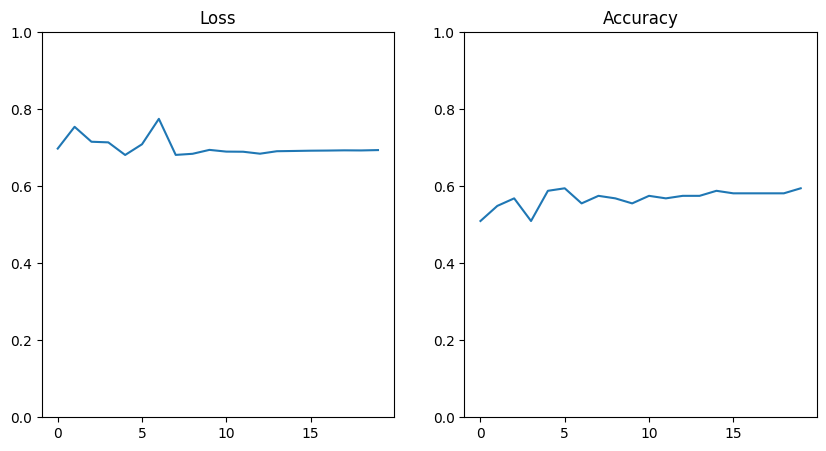

In [16]:
plt.figure(figsize = (10, 5))
plt.subplot(121)
plt.title("Loss")
plt.ylim([0.0, 1.0])
plt.plot(result['loss history']['val'])

plt.subplot(122)
plt.title("Accuracy")
plt.ylim([0.0, 1.0])
plt.plot(result['accuracy history']['val'])

#### Visualizing Prediction

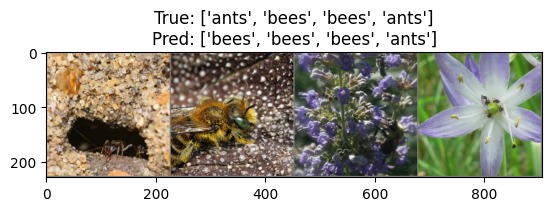

In [17]:
# Interface showing the validation result
model_trained = result['model']

def model_demo(model_trained):
  input, label = next(iter(data_loader['val']))
  input = input.to(device)
  label = label.to(device)
  _, predicted = torch.max(model_trained(input), 1)
  # prepare the grid picture
  grid = torchvision.utils.make_grid(input.cpu())
  imshow(grid, title = 'True: {}'.format([classes[x] for x in label])+
         '\n'+
         'Pred: {}'.format([classes[x] for x in predicted]))

model_demo(model_trained)

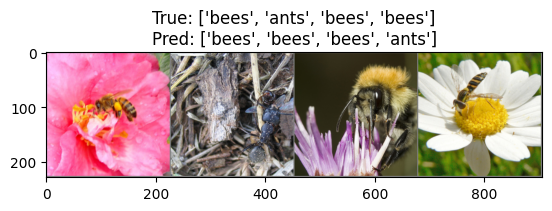

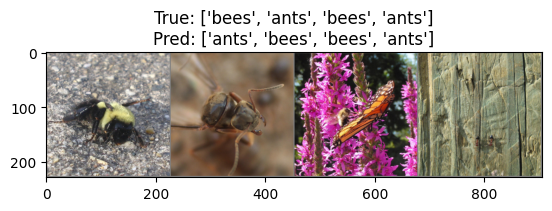

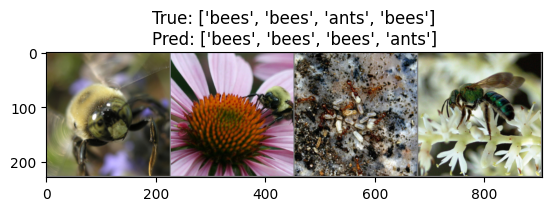

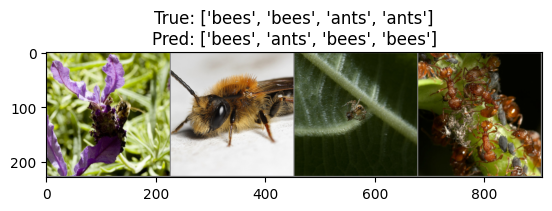

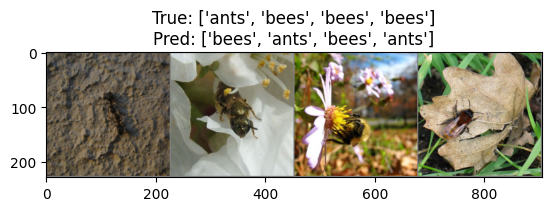

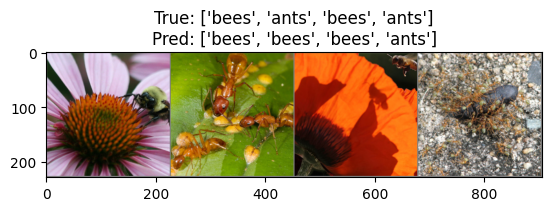

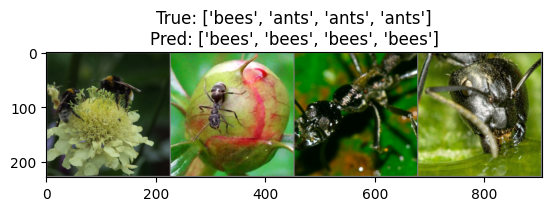

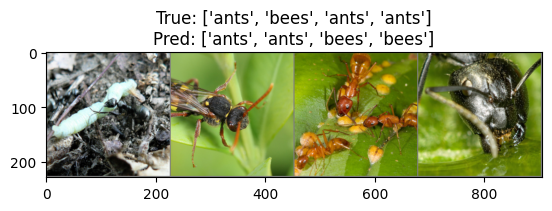

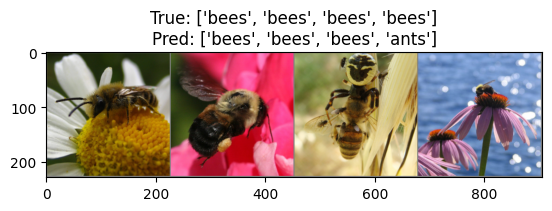

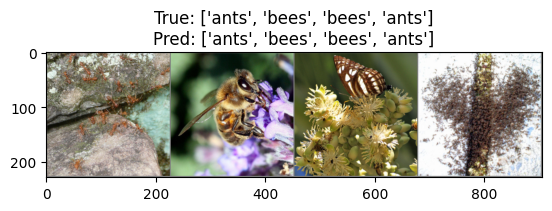

In [18]:
for i in range(10):
  model_demo(model_trained)

The best model accuracy on the validation set was 0.588. Was our model better at catching bees in the picture? Or bees? Let's take a look at the confusion matrix.

In [19]:
labels_true = np.array([])
labels_predicted = np.array([])

for inputs, labels in data_loader['val']:
  inputs = inputs.to(device)
  labels = labels
  labels_true = np.append(labels_true, labels)
  _, predicted = torch.max(model_trained(inputs), 1)
  labels_predicted = np.append(labels_predicted, predicted.cpu())

print(type(labels_true), labels_true.shape)
print(type(labels_predicted), labels_predicted.shape)

<class 'numpy.ndarray'> (153,)
<class 'numpy.ndarray'> (153,)


              precision    recall  f1-score   support

         0.0       0.57      0.44      0.50        70
         1.0       0.61      0.72      0.66        83

    accuracy                           0.59       153
   macro avg       0.59      0.58      0.58       153
weighted avg       0.59      0.59      0.59       153



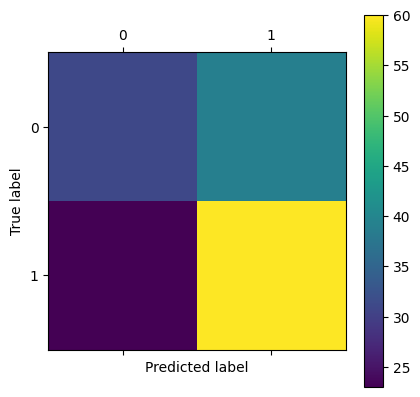

In [20]:
from sklearn import metrics

# report
print(metrics.classification_report(labels_true, labels_predicted))

# confusion matrix
matrix = metrics.confusion_matrix(labels_true, labels_predicted)
plt.matshow(matrix)
plt.colorbar()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

The model doesn't do very well overall, making a slightly better guess on recognizing bee.

#### vs. ResNet18

In [21]:
from torchvision import models

# load ResNet18
model = models.resnet18(pretrained = True)
# Edit the last layer
input_size = model.fc.in_features
model.fc = nn.Linear(input_size, 2)
model = model.to(device)
n_epochs = 20
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
lr_schedule = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.01)
result = train_model(model, loss_function, optimizer, lr_schedule, n_epochs)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 94.5MB/s]


----------
Epoch 1/20


/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Train Loss: 0.599, Accuracy: 0.680
Validation Loss: 0.263, Accuracy: 0.895
----------
Epoch 2/20
Train Loss: 0.494, Accuracy: 0.811
Validation Loss: 0.624, Accuracy: 0.758
----------
Epoch 3/20
Train Loss: 0.617, Accuracy: 0.791
Validation Loss: 0.436, Accuracy: 0.817
----------
Epoch 4/20
Train Loss: 0.542, Accuracy: 0.803
Validation Loss: 0.378, Accuracy: 0.863
----------
Epoch 5/20
Train Loss: 0.542, Accuracy: 0.795
Validation Loss: 0.439, Accuracy: 0.850
----------
Epoch 6/20
Train Loss: 0.450, Accuracy: 0.840
Validation Loss: 0.308, Accuracy: 0.869
----------
Epoch 7/20
Train Loss: 0.331, Accuracy: 0.861
Validation Loss: 0.367, Accuracy: 0.889
----------
Epoch 8/20
Train Loss: 0.499, Accuracy: 0.820
Validation Loss: 0.483, Accuracy: 0.869
----------
Epoch 9/20
Train Loss: 0.320, Accuracy: 0.861
Validation Loss: 0.330, Accuracy: 0.915
----------
Epoch 10/20
Train Loss: 0.371, Accuracy: 0.877
Validation Loss: 0.330, Accuracy: 0.922
----------
Epoch 11/20
Train Loss: 0.333, Accuracy:

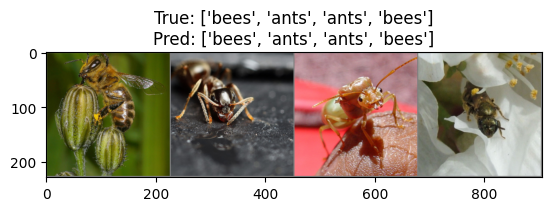

In [22]:
model_trained = result['model']

def model_demo(model_trained):
  input, label = next(iter(data_loader['val']))
  input = input.to(device)
  label = label.to(device)
  _, predicted = torch.max(model_trained(input), 1)
  # Prepare the grid picture
  grid = torchvision.utils.make_grid(input.cpu())
  imshow(grid, title = 'True: {}'.format([classes[x] for x in label])+
         '\n'+
         'Pred: {}'.format([classes[x] for x in predicted]))

model_demo(model_trained)

<class 'numpy.ndarray'> (153,)
<class 'numpy.ndarray'> (153,)
              precision    recall  f1-score   support

         0.0       0.93      0.91      0.92        70
         1.0       0.93      0.94      0.93        83

    accuracy                           0.93       153
   macro avg       0.93      0.93      0.93       153
weighted avg       0.93      0.93      0.93       153



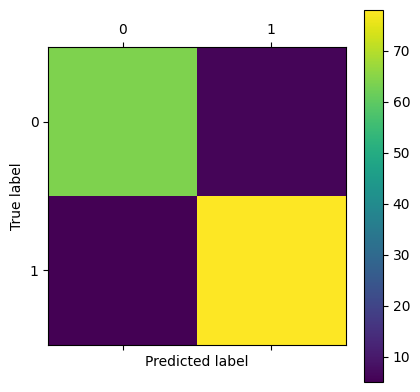

In [23]:
labels_true = np.array([])
labels_predicted = np.array([])

for inputs, labels in data_loader['val']:
  inputs = inputs.to(device)
  labels = labels
  labels_true = np.append(labels_true, labels)
  _, predicted = torch.max(model_trained(inputs), 1)
  labels_predicted = np.append(labels_predicted, predicted.cpu())

print(type(labels_true), labels_true.shape)
print(type(labels_predicted), labels_predicted.shape)

# report
print(metrics.classification_report(labels_true, labels_predicted))

# confusion matrix
matrix = metrics.confusion_matrix(labels_true, labels_predicted)
plt.matshow(matrix)
plt.colorbar()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

Much better metrics!